# Exercice 04 – Extraire les données de contrats de leasing

Le dossier `contrats/` contient 20 contrats de leasing automobile (fictifs), en PDF, issus de trois agences différentes. Chaque agence a sa propre mise en page et son propre vocabulaire (*client* ou *preneur*, *mensualité*, *loyer* ou *redevance*…). Certains contrats font deux pages.

**Objectif** : pour chaque contrat, extraire les informations ci-dessous avec un modèle vision et une **sortie structurée** (schéma Pydantic), les rassembler dans un `DataFrame` **polars**, et mesurer la qualité de l'extraction.

**Serveur** : un modèle vision avec son `mmproj` (voir le cours sur les images). Pensez à vérifier `requests.get(f"{BASE_URL}/props").json()["modalities"]`.

## Les informations à extraire

| Champ | Type | Remarque |
|---|---|---|
| `numero_contrat` | texte | ex. `ALW-2026-1914` |
| `date_contrat` | date | au format `AAAA-MM-JJ` quel que soit le format sur le document |
| `agence` | texte | nom de la société de leasing |
| `client` | texte | le client (ou « preneur »), **pas** le conseiller commercial |
| `vehicule.marque`, `vehicule.modele` | texte | |
| `vehicule.carburant` | choix | `essence`, `diesel`, `hybride`, `hybride rechargeable`, `électrique` |
| `duree_mois`, `km_annuel` | entier | |
| `acompte_eur` | nombre | 0 s'il n'y en a pas |
| `mensualite_tvac_eur` | nombre | TVA comprise ; si le montant a été corrigé à la main, la valeur corrigée |
| `assurance.type` | choix | `omnium`, `mini-omnium`, `rc`, `aucune` |
| `assurance.compagnie` | texte | vide si RC seule ou aucune assurance |
| `assurance.prime_mensuelle_eur` | nombre | 0 si aucune prime séparée |
| `signature_client`, `signature_agence` | booléen | `True` seulement si une signature manuscrite est présente |
| `annule` | booléen | `True` si le document porte une mention d'annulation |

## Ouvrir un PDF en Python

On utilise `pymupdf` (`pip install pymupdf`). Un PDF peut contenir :

- **du texte** (PDF « natif », généré par un logiciel) : `page.get_text()` le renvoie directement ;
- **seulement des images** (PDF **scanné**) : `page.get_text()` renvoie une chaîne vide, il faut transformer la page en image et la donner au modèle vision.

Dans ce lot, **certains contrats sont natifs, d'autres sont des scans**. Le code suivant vous montre la différence.

In [3]:
import pymupdf
print(pymupdf.__version__)


1.28.2


2 page(s)
Scan (pas de texte)


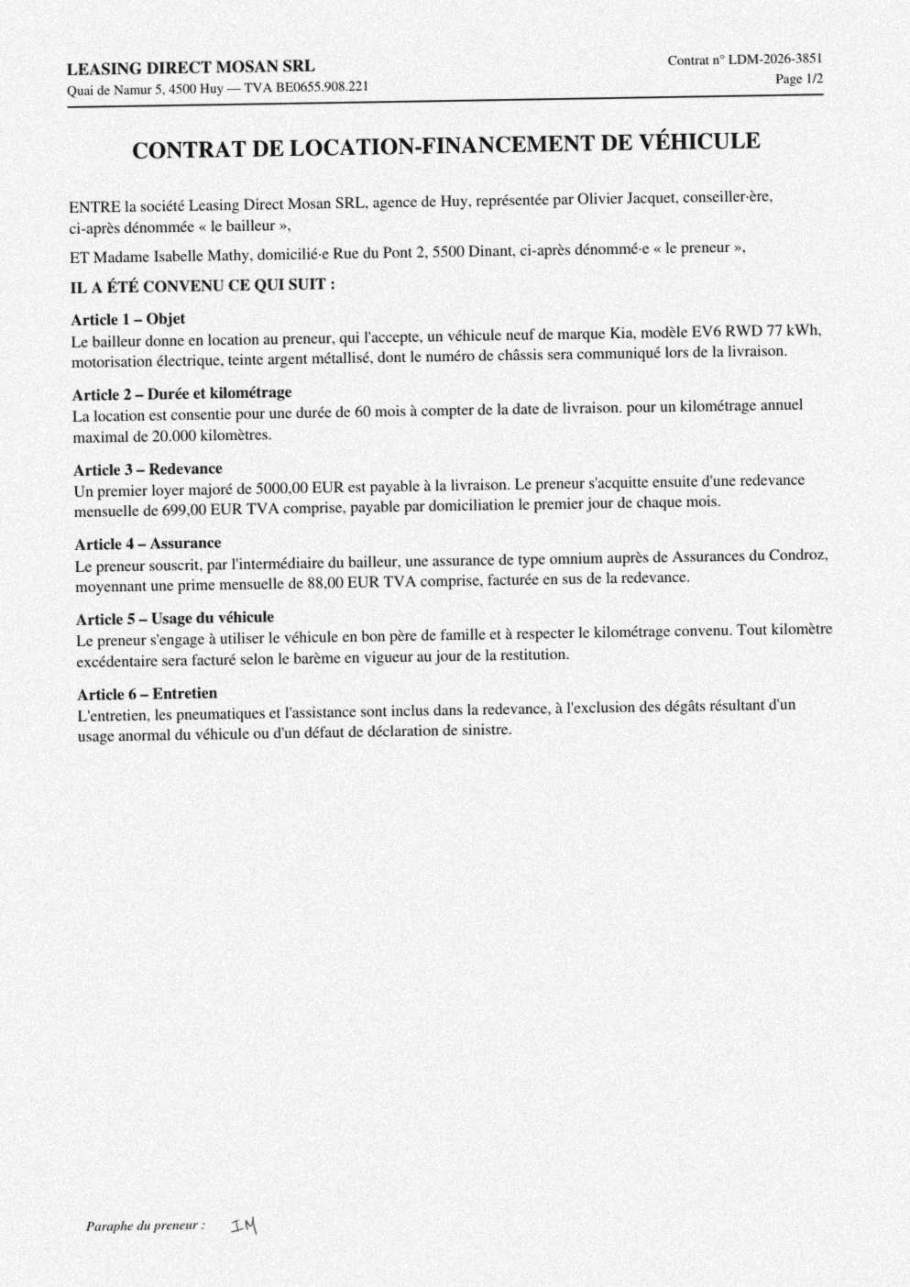

In [55]:
import base64
import pymupdf
from IPython.display import Image, display

doc = pymupdf.open(
    "/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_07.pdf"
)  # essayez aussi contrat_04.pdf (scan)
print(len(doc), "page(s)")

# 1) Le texte, s'il existe
texte = doc[0].get_text()
print("Scan (pas de texte)" if not texte.strip() else texte[:500])

# 2) La page en image : fonctionne dans tous les cas
pix = doc[0].get_pixmap(dpi=110)       # 110 dpi : lisible, sans exploser le nombre de tokens
png = pix.tobytes("png")
display(Image(png, width=450))

# 3) L'image prête à être envoyée au modèle (comme dans le cours sur les images)
data_uri = "data:image/png;base64," + base64.b64encode(png).decode()




1 page(s)
Scan (pas de texte)


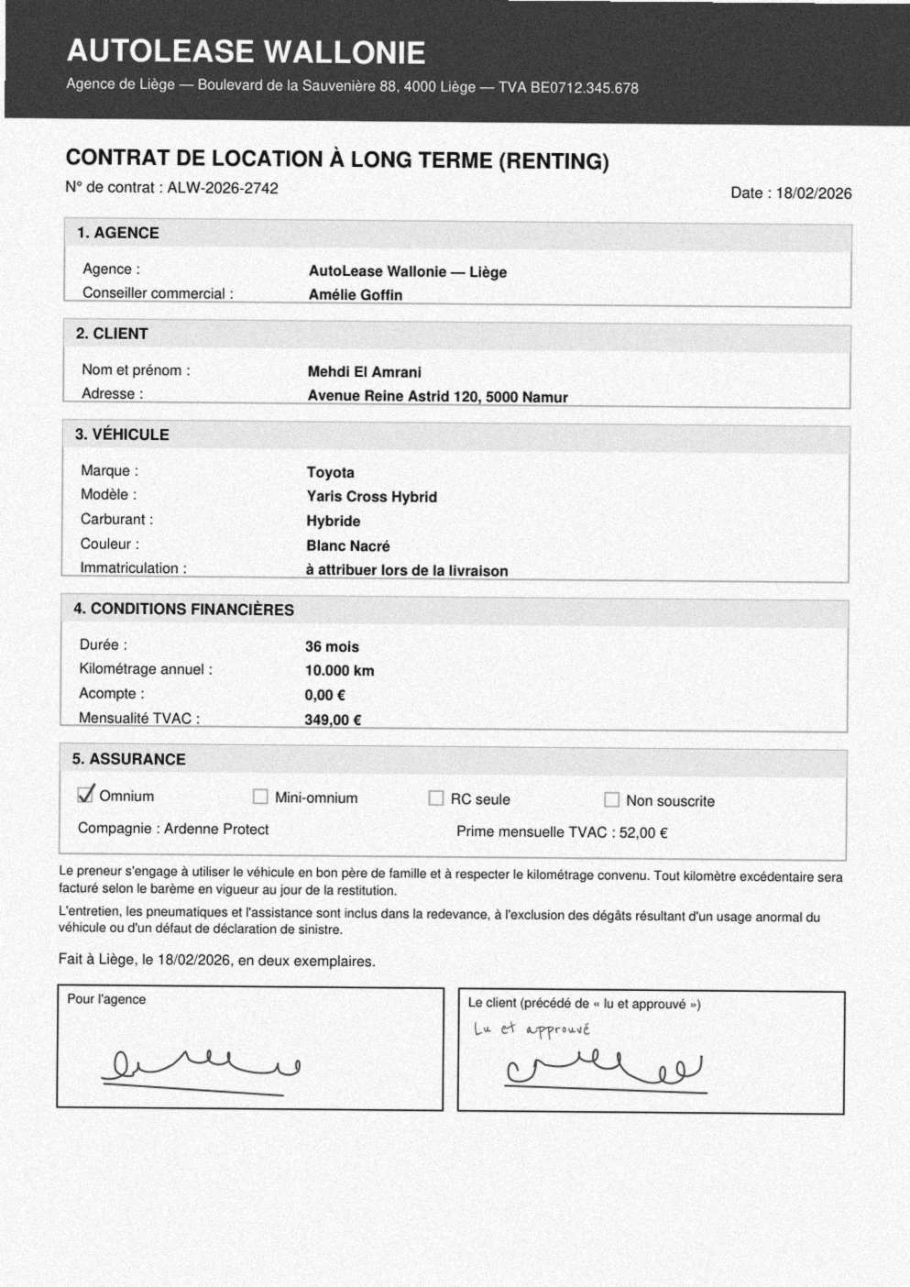

In [53]:
doc = pymupdf.open(
    "/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_04.pdf"
)  # essayez aussi contrat_04.pdf (scan)
print(len(doc), "page(s)")

# 1) Le texte, s'il existe
texte = doc[0].get_text()
print("Scan (pas de texte)" if not texte.strip() else texte[:500])

# 2) La page en image : fonctionne dans tous les cas
pix = doc[0].get_pixmap(dpi=110)       # 110 dpi : lisible, sans exploser le nombre de tokens
png = pix.tobytes("png")
display(Image(png, width=450))

# 3) L'image prête à être envoyée au modèle (comme dans le cours sur les images)
data_uri = "data:image/png;base64," + base64.b64encode(png).decode()




## À faire

1. Écrire les classes Pydantic correspondant au tableau des champs (`Vehicule`, `Assurance`, `Contrat`).
2. Écrire `extraire(chemin_pdf) -> Contrat` qui envoie **toutes les pages** du contrat au modèle, avec `response_format` et le schéma.
3. Boucler sur les 20 contrats, enregistrer les résultats (plus `prompt_tokens` et la durée) dans `resultats_contrats.csv`.
4. Évaluer : le fichier `verite_terrain.json` avec les valeurs attendues vous sera donné en fin de séance. Calculez le taux de bonnes réponses **par champ**, puis séparément pour les contrats **natifs** et **scannés**.
5. Répondez : quels champs posent le plus de problèmes ? Pourquoi ? Qu'est-ce qui change entre un PDF natif et un scan ?

> **Tips**
> - Le system prompt compte autant que le schéma : rappelez les règles du tableau (TVAC, corrections manuscrites, client ≠ conseiller, ce qui compte comme signature).
> - Les `description` de `Field(...)` sont envoyées au modèle avec le schéma : utilisez-les.
> - Une page A4 à 110 dpi coûte environ un millier de tokens : vérifiez que votre `-c` suffit pour un contrat de deux pages.
> - `temperature=0` et vérifiez `finish_reason`.
> - `pl.DataFrame(liste_de_dicts)` puis `.write_csv(...)` ; `pl.read_json("verite_terrain.json")` lit la vérité terrain.
> - Pour les PDF natifs, vous pouvez **aussi** envoyer le texte extrait. Est-ce que ça aide ? Toujours ?

In [21]:
from pydantic import BaseModel, Field
from datetime import date
from typing import Literal


class Vehicule(BaseModel):
    marque: str
    modele: str
    carburant: Literal[
        "essence",
        "diesel",
        "hybride",
        "hybride rechargeable",
        "électrique"
    ]


class Assurance(BaseModel):
    type: Literal[
        "omnium",
        "mini-omnium",
        "rc",
        "aucune"
    ]
    
    compagnie: str = Field(
        ...,
        description="Vide si RC seule ou aucune assurance."
    )
    
    prime_mensuelle_eur: float = Field(
        ...,
        description="0 si aucune prime séparée."
    )


class ContratLeasing(BaseModel):
    numero_contrat: str
    
    date_contrat: date = Field(
        ...,
        description="Date du contrat au format AAAA-MM-JJ."
    )
    
    agence: str
    
    client: str = Field(
        ...,
        description="Le client ou preneur, pas le conseiller commercial."
    )
    
    vehicule: Vehicule
    
    duree_mois: int
    km_annuel: int
    
    acompte_eur: float = Field(
        ...,
        description="0 s'il n'y a pas d'acompte."
    )
    
    mensualite_tvac_eur: float = Field(
        ...,
        description="Mensualité TVA comprise. Si le montant a été corrigé à la main, utiliser la valeur corrigée."
    )
    
    assurance: Assurance
    
    signature_client: bool = Field(
        ...,
        description="True seulement si une signature manuscrite du client est présente."
    )
    
    signature_agence: bool = Field(
        ...,
        description="True seulement si une signature manuscrite de l'agence est présente."
    )
    
    annule: bool = Field(
        ...,
        description="True si le document porte une mention d'annulation."
    )

In [22]:
ContratLeasing.model_json_schema()

{'$defs': {'Assurance': {'properties': {'type': {'enum': ['omnium',
      'mini-omnium',
      'rc',
      'aucune'],
     'title': 'Type',
     'type': 'string'},
    'compagnie': {'description': 'Vide si RC seule ou aucune assurance.',
     'title': 'Compagnie',
     'type': 'string'},
    'prime_mensuelle_eur': {'description': '0 si aucune prime séparée.',
     'title': 'Prime Mensuelle Eur',
     'type': 'number'}},
   'required': ['type', 'compagnie', 'prime_mensuelle_eur'],
   'title': 'Assurance',
   'type': 'object'},
  'Vehicule': {'properties': {'marque': {'title': 'Marque', 'type': 'string'},
    'modele': {'title': 'Modele', 'type': 'string'},
    'carburant': {'enum': ['essence',
      'diesel',
      'hybride',
      'hybride rechargeable',
      'électrique'],
     'title': 'Carburant',
     'type': 'string'}},
   'required': ['marque', 'modele', 'carburant'],
   'title': 'Vehicule',
   'type': 'object'}},
 'properties': {'numero_contrat': {'title': 'Numero Contrat',
   

In [23]:
from pathlib import Path

dossier = Path(
    "/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats"
)

fichiers_pdf = list(dossier.glob("*.pdf"))

print(len(fichiers_pdf))
print(fichiers_pdf)

20
[PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_19.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_13.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_15.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_09.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_02.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_12.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_10.pdf'), PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/contrats/contrat_06.pdf'), PosixPath('/home/bm/formation/formation/cour

In [25]:
def extraire1(chemin_pdf):
    doc = pymupdf.open(chemin_pdf)

    images = []

    for page in doc:
        pix = page.get_pixmap(dpi=110)
        png = pix.tobytes("png")
        data_uri = "data:image/png;base64," + base64.b64encode(png).decode()
        images.append(data_uri)

    return images

Nombre de pages : 2



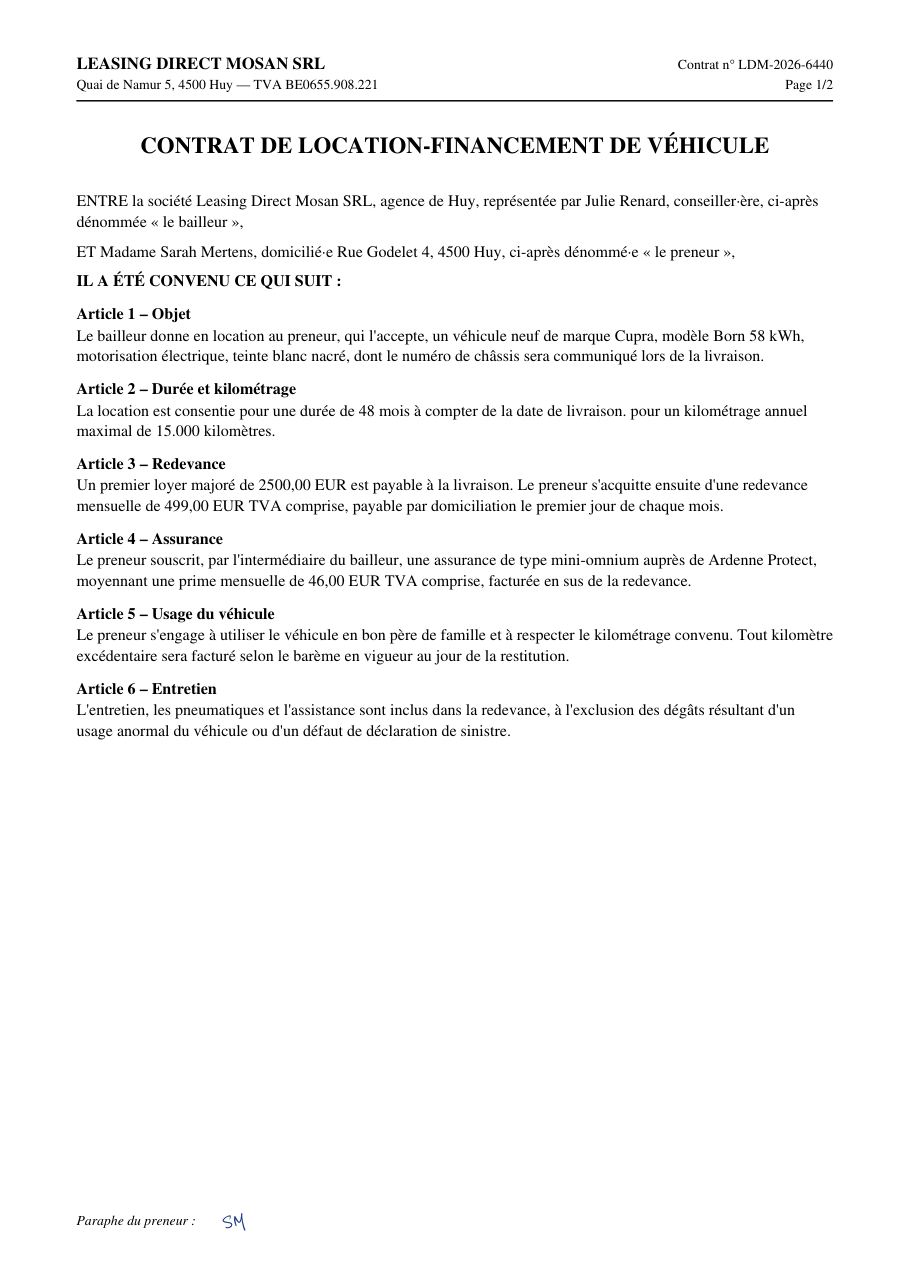


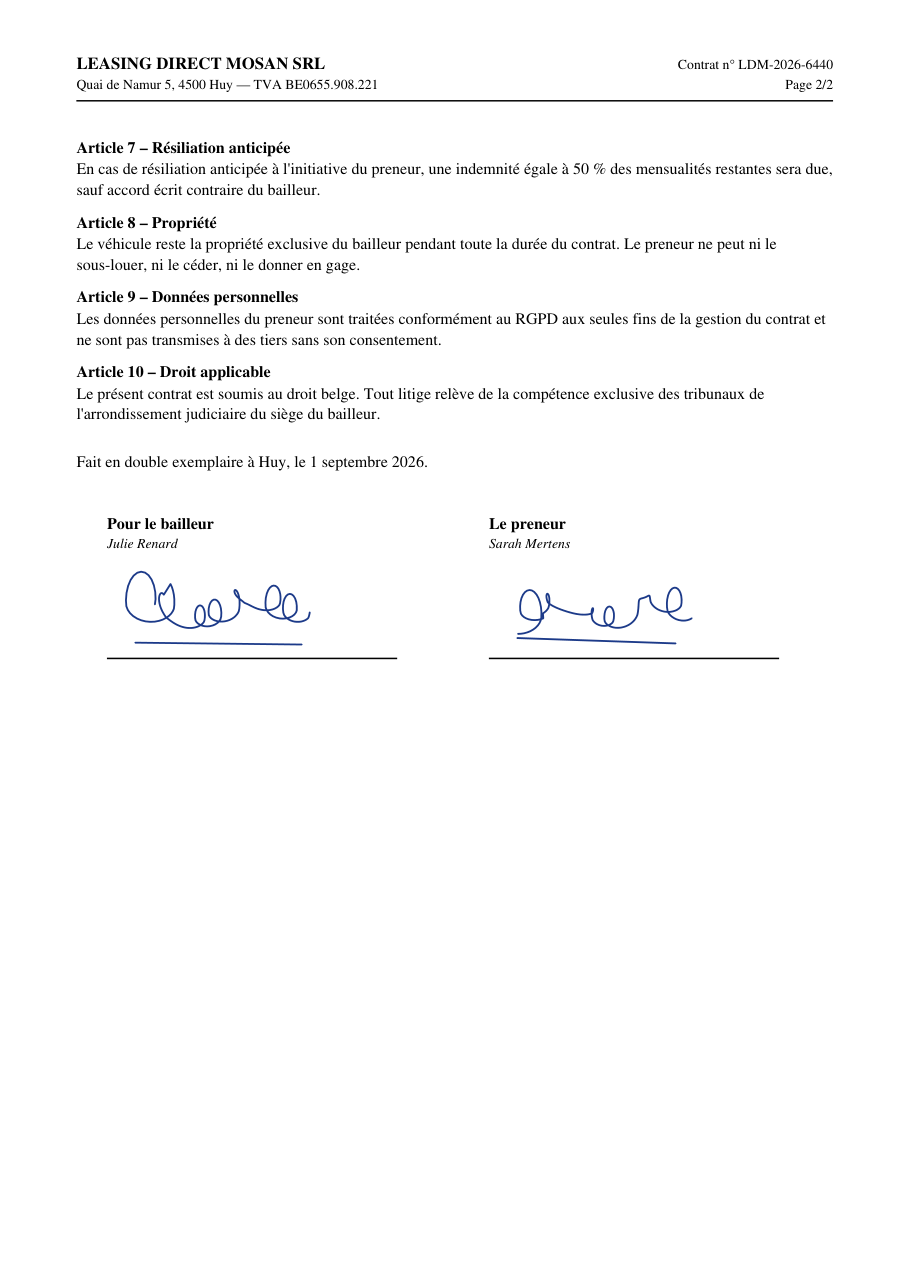

In [26]:
images = extraire1(fichiers_pdf[0])

print("Nombre de pages :", len(images))

for img in images:
    display(Image(url=img, width=450))

In [27]:
from openai import OpenAI

client = OpenAI(
    base_url="http://127.0.0.1:9931/v1",
    api_key="not-needed"
)

In [37]:
def extraire(chemin_pdf):
    # 1. Ouvrir le PDF
    doc = pymupdf.open(chemin_pdf)

    # 2. Commencer le contenu du message avec l'instruction
    content = [
        {
            "type": "text",
            "text": "Extrais les informations de ce contrat de leasing selon le schéma fourni."
        }
    ]

    # 3. Ajouter TOUTES les pages comme images
    for page in doc:
        pix = page.get_pixmap(dpi=110)
        png = pix.tobytes("png")

        data_uri = (
            "data:image/png;base64,"
            + base64.b64encode(png).decode()
        )

        content.append(
            {
                "type": "image_url",
                "image_url": {
                    "url": data_uri
                }
            }
        )

    # 4. Envoyer au modèle
    r = client.chat.completions.create(
        model="local",
        messages=[
    {
        "role": "system",
        "content": """
Tu extrais les informations d'un contrat de leasing.

Respecte strictement les règles suivantes :
- La mensualite_tvac_eur doit être le montant TVA comprise.
- Si un montant a été corrigé à la main, utilise la valeur corrigée.
- Le client est le client ou preneur, jamais le conseiller commercial.
- signature_client et signature_agence valent True uniquement si une signature manuscrite est présente.
"""
    },
    {
        "role": "user",
        "content": content
    }
],
        temperature=0.2,
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "ContratLeasing",
                "schema": ContratLeasing.model_json_schema()
            }
        },
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    # 5. Valider le JSON reçu avec Pydantic
    contrat = ContratLeasing.model_validate_json(
        r.choices[0].message.content
    )

    return contrat, r.usage.prompt_tokens

In [29]:
contrat_test = extraire(fichiers_pdf[0])
print(contrat_test)

(ContratLeasing(numero_contrat='LDM-2026-6440', date_contrat=datetime.date(2026, 9, 1), agence='Huy', client='Madame Sarah Mertens', vehicule=Vehicule(marque='Cupra', modele='Born 58 kWh', carburant='électrique'), duree_mois=48, km_annuel=15000, acompte_eur=2500.0, mensualite_tvac_eur=499.0, assurance=Assurance(type='mini-omnium', compagnie='Ardenne Protect', prime_mensuelle_eur=46.0), signature_client=True, signature_agence=True, annule=False), 2271)


In [38]:
contrat_test, tokens_test = extraire(fichiers_pdf[0])

print(contrat_test)
print("\nPrompt tokens :", tokens_test)

numero_contrat='ALW-2026-4244' date_contrat=datetime.date(2026, 1, 12) agence='AutoLease Wallonie — Namur' client='Marie Lecomte' vehicule=Vehicule(marque='Peugeot', modele='308 SW 1.2 PureTech', carburant='essence') duree_mois=48 km_annuel=15000 acompte_eur=1500.0 mensualite_tvac_eur=389.0 assurance=Assurance(type='omnium', compagnie='Mosane Assurances', prime_mensuelle_eur=58.0) signature_client=True signature_agence=True annule=False

Prompt tokens : 1247


In [39]:
import time

debut = time.time()

contrat_test, tokens_test = extraire(fichiers_pdf[0])

fin = time.time()

duree = fin - debut

print("Durée :", duree, "secondes")
print("Prompt tokens :", tokens_test)

Durée : 9.181795597076416 secondes
Prompt tokens : 1247


In [40]:
import time

# Liste qui contiendra le résultat de chaque contrat
resultats = []

# Trier les fichiers pour les traiter dans l'ordre :
# contrat_01.pdf, contrat_02.pdf, contrat_03.pdf, etc.
fichiers_pdf = sorted(fichiers_pdf)

# Nombre total de contrats à traiter
nombre_total = len(fichiers_pdf)

# Boucle sur tous les fichiers PDF
for numero, fichier_pdf in enumerate(fichiers_pdf, start=1):

    # Afficher la progression avant de commencer le contrat
    print(f"[{numero}/{nombre_total}] Traitement de {fichier_pdf.name}...")

    # Enregistrer l'heure de début
    debut = time.time()

    # Extraire les informations du contrat avec le LLM
    # La fonction retourne :
    # 1. le contrat structuré avec Pydantic
    # 2. le nombre de prompt_tokens utilisés
    contrat, prompt_tokens = extraire(fichier_pdf)

    # Calculer la durée totale du traitement
    duree = time.time() - debut

    # Transformer l'objet Pydantic en dictionnaire Python
    resultat = contrat.model_dump()

    # Ajouter les informations techniques demandées dans l'exercice
    resultat["fichier"] = fichier_pdf.name
    resultat["prompt_tokens"] = prompt_tokens
    resultat["duree_secondes"] = duree

    # Ajouter ce contrat à la liste générale des résultats
    resultats.append(resultat)

    # Confirmation pour ce contrat
    print(
        f"    ✓ terminé — "
        f"{prompt_tokens} tokens — "
        f"{duree:.2f} secondes"
    )


# Vérification finale
if len(resultats) == nombre_total:
    print(
        f"\n✓ TOUS LES CONTRATS SONT TERMINÉS : "
        f"{len(resultats)}/{nombre_total}"
    )
else:
    print(
        f"\n⚠ CONTRATS MANQUANTS : "
        f"{len(resultats)}/{nombre_total} traités"
    )

[1/20] Traitement de contrat_01.pdf...
    ✓ terminé — 1247 tokens — 9.18 secondes
[2/20] Traitement de contrat_02.pdf...
    ✓ terminé — 1247 tokens — 10.79 secondes
[3/20] Traitement de contrat_03.pdf...
    ✓ terminé — 2369 tokens — 12.54 secondes
[4/20] Traitement de contrat_04.pdf...
    ✓ terminé — 1247 tokens — 11.11 secondes
[5/20] Traitement de contrat_05.pdf...
    ✓ terminé — 1247 tokens — 10.97 secondes
[6/20] Traitement de contrat_06.pdf...
    ✓ terminé — 1247 tokens — 11.06 secondes
[7/20] Traitement de contrat_07.pdf...
    ✓ terminé — 2369 tokens — 13.03 secondes
[8/20] Traitement de contrat_08.pdf...
    ✓ terminé — 1247 tokens — 11.13 secondes
[9/20] Traitement de contrat_09.pdf...
    ✓ terminé — 1247 tokens — 11.02 secondes
[10/20] Traitement de contrat_10.pdf...
    ✓ terminé — 1247 tokens — 11.20 secondes
[11/20] Traitement de contrat_11.pdf...
    ✓ terminé — 2369 tokens — 12.58 secondes
[12/20] Traitement de contrat_12.pdf...
    ✓ terminé — 1247 tokens — 11.21

In [41]:
import polars as pl

# Transformer la liste des dictionnaires en DataFrame Polars
df_resultats = pl.DataFrame(resultats)

# Afficher le DataFrame avec les structures imbriquées
display(df_resultats)

# Aplatir "vehicule" et "assurance" pour pouvoir enregistrer en CSV
df_resultats_csv = df_resultats.unnest(["vehicule", "assurance"])

# Vérifier le résultat aplati
display(df_resultats_csv)

# Enregistrer les résultats dans le fichier CSV
df_resultats_csv.write_csv("resultats_contrats.csv")

# Confirmation
print(
    f"✓ resultats_contrats.csv créé avec "
    f"{df_resultats_csv.height} contrats."
)

numero_contrat,date_contrat,agence,client,vehicule,duree_mois,km_annuel,acompte_eur,mensualite_tvac_eur,assurance,signature_client,signature_agence,annule,fichier,prompt_tokens,duree_secondes
str,date,str,str,struct[3],i64,i64,f64,f64,struct[3],bool,bool,bool,str,i64,f64
"""ALW-2026-4244""",2026-01-12,"""AutoLease Wallonie — Namur""","""Marie Lecomte""","{""Peugeot"",""308 SW 1.2 PureTech"",""essence""}",48,15000,1500.0,389.0,"{""omnium"",""Mosane Assurances"",58.0}",true,true,false,"""contrat_01.pdf""",1247,9.183132
"""MOB-2026-4619""",2026-07-27,"""Mons""","""Jonathan Pirard""","{""Volkswagen"",""ID.3 Pro"",""électrique""}",60,12500,3000.0,459.0,"{""omnium"",""Ardenne Protect"",71.5}",true,true,false,"""contrat_02.pdf""",1247,10.7948
"""LDM-2026-6898""",2026-02-03,"""Leasing Direct Mosan SRL""","""Claire Henrard""","{""Skoda"",""Octavia Combi 2.0 TDI"",""diesel""}",48,25000,2000.0,429.0,"{""mini-omnium"",""Ardenne Protect"",44.0}",true,true,false,"""contrat_03.pdf""",2369,12.543833
"""ALW-2026-2742""",2026-02-18,"""AutoLease Wallonie — Liège""","""Mehdi El Amrani""","{""Toyota"",""Yaris Cross Hybrid"",""hybride""}",36,10000,0.0,349.0,"{""omnium"",""Ardenne Protect"",52.0}",true,true,false,"""contrat_04.pdf""",1247,11.106849
"""MOB-2026-7539""",2026-02-03,"""Mons""","""Laurence Gilson""","{""Renault"",""Clio TCE 90"",""essence""}",48,10000,1000.0,279.0,"{""rc"",""non specifiee"",0.0}",false,true,false,"""contrat_05.pdf""",1247,10.967771
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""MOB-2026-7397""",2026-07-21,"""Mons""","""Arnaud Bastin""","{""MG"",""MG4 Electric Standard"",""électrique""}",60,15000,0.0,339.0,"{""omnium"",""Assurances du Condroz"",55.0}",true,false,false,"""contrat_16.pdf""",1247,10.999287
"""ALW-2026-7995""",2026-08-04,"""AutoLease Wallonie — Liège""","""Émilie Dufour""","{""Opel"",""Corsa 1.2 Turbo"",""essence""}",48,10000,1000.0,269.0,"{""omnium"",""Ardenne Protect"",48.0}",true,true,false,"""contrat_17.pdf""",1247,11.114693
"""MOB-2026-7465""",2026-08-18,"""Mons""","""Luc Materne""","{""Tesla"",""Model 3 Propulsion"",""électrique""}",36,20000,5000.0,629.0,"{""omnium"",""Mosane Assurances"",92.0}",true,true,false,"""contrat_18.pdf""",1247,11.116946


numero_contrat,date_contrat,agence,client,marque,modele,carburant,duree_mois,km_annuel,acompte_eur,mensualite_tvac_eur,type,compagnie,prime_mensuelle_eur,signature_client,signature_agence,annule,fichier,prompt_tokens,duree_secondes
str,date,str,str,str,str,str,i64,i64,f64,f64,str,str,f64,bool,bool,bool,str,i64,f64
"""ALW-2026-4244""",2026-01-12,"""AutoLease Wallonie — Namur""","""Marie Lecomte""","""Peugeot""","""308 SW 1.2 PureTech""","""essence""",48,15000,1500.0,389.0,"""omnium""","""Mosane Assurances""",58.0,true,true,false,"""contrat_01.pdf""",1247,9.183132
"""MOB-2026-4619""",2026-07-27,"""Mons""","""Jonathan Pirard""","""Volkswagen""","""ID.3 Pro""","""électrique""",60,12500,3000.0,459.0,"""omnium""","""Ardenne Protect""",71.5,true,true,false,"""contrat_02.pdf""",1247,10.7948
"""LDM-2026-6898""",2026-02-03,"""Leasing Direct Mosan SRL""","""Claire Henrard""","""Skoda""","""Octavia Combi 2.0 TDI""","""diesel""",48,25000,2000.0,429.0,"""mini-omnium""","""Ardenne Protect""",44.0,true,true,false,"""contrat_03.pdf""",2369,12.543833
"""ALW-2026-2742""",2026-02-18,"""AutoLease Wallonie — Liège""","""Mehdi El Amrani""","""Toyota""","""Yaris Cross Hybrid""","""hybride""",36,10000,0.0,349.0,"""omnium""","""Ardenne Protect""",52.0,true,true,false,"""contrat_04.pdf""",1247,11.106849
"""MOB-2026-7539""",2026-02-03,"""Mons""","""Laurence Gilson""","""Renault""","""Clio TCE 90""","""essence""",48,10000,1000.0,279.0,"""rc""","""non specifiee""",0.0,false,true,false,"""contrat_05.pdf""",1247,10.967771
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""MOB-2026-7397""",2026-07-21,"""Mons""","""Arnaud Bastin""","""MG""","""MG4 Electric Standard""","""électrique""",60,15000,0.0,339.0,"""omnium""","""Assurances du Condroz""",55.0,true,false,false,"""contrat_16.pdf""",1247,10.999287
"""ALW-2026-7995""",2026-08-04,"""AutoLease Wallonie — Liège""","""Émilie Dufour""","""Opel""","""Corsa 1.2 Turbo""","""essence""",48,10000,1000.0,269.0,"""omnium""","""Ardenne Protect""",48.0,true,true,false,"""contrat_17.pdf""",1247,11.114693
"""MOB-2026-7465""",2026-08-18,"""Mons""","""Luc Materne""","""Tesla""","""Model 3 Propulsion""","""électrique""",36,20000,5000.0,629.0,"""omnium""","""Mosane Assurances""",92.0,true,true,false,"""contrat_18.pdf""",1247,11.116946


✓ resultats_contrats.csv créé avec 20 contrats.


In [42]:
verite = pl.read_json(
    "/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/verite_terrain.json"
)

display(verite)

print("Dimensions :", verite.shape)
print("Colonnes :", verite.columns)


fichier,numero_contrat,date_contrat,agence,ville_agence,conseiller,client,adresse_client,marque,modele,carburant,duree_mois,km_annuel,acompte_eur,mensualite_tvac_eur,assurance,assurance_compagnie,assurance_prime_mensuelle_eur,signature_client,signature_agence,annule,mise_en_page,format,nb_pages,pieges
str,str,str,str,str,str,str,str,str,str,str,i64,i64,f64,f64,str,str,f64,bool,bool,bool,str,str,i64,str
"""contrat_01.pdf""","""ALW-2026-4244""","""2026-01-12""","""AutoLease Wallonie""","""Namur""","""Nathalie Collard""","""Marie Lecomte""","""Rue des Tilleuls 8, 5020 Malon…","""Peugeot""","""308 SW 1.2 PureTech""","""essence""",48,15000,1500.0,389.0,"""omnium""","""Mosane Assurances""",58.0,true,true,false,"""A""","""natif""",1,""""""
"""contrat_02.pdf""","""MOB-2026-4619""","""2026-01-27""","""Mobilis Lease""","""Mons""","""Thomas Lambert""","""Jonathan Pirard""","""Rue du Moulin 44, 1340 Ottigni…","""Volkswagen""","""ID.3 Pro""","""électrique""",60,12500,3000.0,459.0,"""omnium""","""Ardenne Protect""",71.5,true,true,false,"""B""","""natif""",1,"""montants HTVA et TVAC affichés"""
"""contrat_03.pdf""","""LDM-2026-6898""","""2026-02-03""","""Leasing Direct Mosan""","""Dinant""","""Olivier Jacquet""","""Claire Henrard""","""Rue Saint-Pierre 19, 4520 Wanz…","""Skoda""","""Octavia Combi 2.0 TDI""","""diesel""",48,25000,2000.0,429.0,"""mini-omnium""","""Ardenne Protect""",44.0,true,true,false,"""C""","""natif""",2,"""2 pages, signatures en page 2 …"
"""contrat_04.pdf""","""ALW-2026-2742""","""2026-02-18""","""AutoLease Wallonie""","""Liège""","""Amélie Goffin""","""Mehdi El Amrani""","""Avenue Reine Astrid 120, 5000 …","""Toyota""","""Yaris Cross Hybrid""","""hybride""",36,10000,0.0,349.0,"""omnium""","""Ardenne Protect""",52.0,true,true,false,"""A""","""scan""",1,"""PDF scanné (pas de texte extra…"
"""contrat_05.pdf""","""MOB-2026-7539""","""2026-03-02""","""Mobilis Lease""","""Mons""","""Nathalie Collard""","""Laurence Gilson""","""Rue de la Station 3, 7011 Ghli…","""Renault""","""Clio TCe 90""","""essence""",48,10000,1000.0,279.0,"""rc""","""""",0.0,false,true,false,"""B""","""natif""",1,"""signature client manquante | m…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""contrat_16.pdf""","""MOB-2026-7397""","""2026-07-21""","""Mobilis Lease""","""Mons""","""Olivier Jacquet""","""Arnaud Bastin""","""Rue du Château 12, 7020 Nimy""","""MG""","""MG4 Electric Standard""","""électrique""",60,15000,0.0,339.0,"""omnium""","""Assurances du Condroz""",55.0,true,false,false,"""B""","""natif""",1,"""signature agence manquante | m…"
"""contrat_17.pdf""","""ALW-2026-7995""","""2026-08-04""","""AutoLease Wallonie""","""Liège""","""Amélie Goffin""","""Émilie Dufour""","""Rue Albert Ier 50, 4280 Hannut""","""Opel""","""Corsa 1.2 Turbo""","""essence""",48,10000,1000.0,269.0,"""omnium""","""Ardenne Protect""",48.0,true,true,false,"""A""","""natif""",1,"""mensualité corrigée à la main …"
"""contrat_18.pdf""","""MOB-2026-7465""","""2026-08-18""","""Mobilis Lease""","""Mons""","""Olivier Jacquet""","""Luc Materne""","""Rue de Jodoigne 8, 1370 Jodoig…","""Tesla""","""Model 3 Propulsion""","""électrique""",36,20000,5000.0,629.0,"""omnium""","""Mosane Assurances""",92.0,true,true,false,"""B""","""scan""",1,"""PDF scanné | montants HTVA et …"


Dimensions : (20, 25)
Colonnes : ['fichier', 'numero_contrat', 'date_contrat', 'agence', 'ville_agence', 'conseiller', 'client', 'adresse_client', 'marque', 'modele', 'carburant', 'duree_mois', 'km_annuel', 'acompte_eur', 'mensualite_tvac_eur', 'assurance', 'assurance_compagnie', 'assurance_prime_mensuelle_eur', 'signature_client', 'signature_agence', 'annule', 'mise_en_page', 'format', 'nb_pages', 'pieges']


In [43]:
from pathlib import Path

dossier_exercice = Path(
    "/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing"
)

list(dossier_exercice.glob("*.json"))


[PosixPath('/home/bm/formation/formation/cours_llama/04_contrats_leasing/04_contrats_leasing/verite_terrain.json')]

In [44]:
print("=== EXTRACTION ===")
print(df_resultats_csv.columns)

print("\n=== VÉRITÉ TERRAIN ===")
print(verite.columns)

=== EXTRACTION ===
['numero_contrat', 'date_contrat', 'agence', 'client', 'marque', 'modele', 'carburant', 'duree_mois', 'km_annuel', 'acompte_eur', 'mensualite_tvac_eur', 'type', 'compagnie', 'prime_mensuelle_eur', 'signature_client', 'signature_agence', 'annule', 'fichier', 'prompt_tokens', 'duree_secondes']

=== VÉRITÉ TERRAIN ===
['fichier', 'numero_contrat', 'date_contrat', 'agence', 'ville_agence', 'conseiller', 'client', 'adresse_client', 'marque', 'modele', 'carburant', 'duree_mois', 'km_annuel', 'acompte_eur', 'mensualite_tvac_eur', 'assurance', 'assurance_compagnie', 'assurance_prime_mensuelle_eur', 'signature_client', 'signature_agence', 'annule', 'mise_en_page', 'format', 'nb_pages', 'pieges']


In [45]:
verite_test = verite.filter(
    pl.col("fichier") == fichiers_pdf[0].name
)

display(verite_test)

fichier,numero_contrat,date_contrat,agence,ville_agence,conseiller,client,adresse_client,marque,modele,carburant,duree_mois,km_annuel,acompte_eur,mensualite_tvac_eur,assurance,assurance_compagnie,assurance_prime_mensuelle_eur,signature_client,signature_agence,annule,mise_en_page,format,nb_pages,pieges
str,str,str,str,str,str,str,str,str,str,str,i64,i64,f64,f64,str,str,f64,bool,bool,bool,str,str,i64,str
"""contrat_01.pdf""","""ALW-2026-4244""","""2026-01-12""","""AutoLease Wallonie""","""Namur""","""Nathalie Collard""","""Marie Lecomte""","""Rue des Tilleuls 8, 5020 Malon…","""Peugeot""","""308 SW 1.2 PureTech""","""essence""",48,15000,1500.0,389.0,"""omnium""","""Mosane Assurances""",58.0,true,true,false,"""A""","""natif""",1,""""""


In [46]:
df_eval = df_resultats_csv.rename({
    "type": "assurance",
    "compagnie": "assurance_compagnie",
    "prime_mensuelle_eur": "assurance_prime_mensuelle_eur"
})

print(df_eval.columns)

['numero_contrat', 'date_contrat', 'agence', 'client', 'marque', 'modele', 'carburant', 'duree_mois', 'km_annuel', 'acompte_eur', 'mensualite_tvac_eur', 'assurance', 'assurance_compagnie', 'assurance_prime_mensuelle_eur', 'signature_client', 'signature_agence', 'annule', 'fichier', 'prompt_tokens', 'duree_secondes']


In [47]:
# Joindre les extractions avec la vérité terrain
comparaison = df_eval.join(
    verite,
    on="fichier",
    how="inner",
    suffix="_verite"
)

print("Dimensions :", comparaison.shape)
display(comparaison)

Dimensions : (20, 44)


numero_contrat,date_contrat,agence,client,marque,modele,carburant,duree_mois,km_annuel,acompte_eur,mensualite_tvac_eur,assurance,assurance_compagnie,assurance_prime_mensuelle_eur,signature_client,signature_agence,annule,fichier,prompt_tokens,duree_secondes,numero_contrat_verite,date_contrat_verite,agence_verite,ville_agence,conseiller,client_verite,adresse_client,marque_verite,modele_verite,carburant_verite,duree_mois_verite,km_annuel_verite,acompte_eur_verite,mensualite_tvac_eur_verite,assurance_verite,assurance_compagnie_verite,assurance_prime_mensuelle_eur_verite,signature_client_verite,signature_agence_verite,annule_verite,mise_en_page,format,nb_pages,pieges
str,date,str,str,str,str,str,i64,i64,f64,f64,str,str,f64,bool,bool,bool,str,i64,f64,str,str,str,str,str,str,str,str,str,str,i64,i64,f64,f64,str,str,f64,bool,bool,bool,str,str,i64,str
"""ALW-2026-4244""",2026-01-12,"""AutoLease Wallonie — Namur""","""Marie Lecomte""","""Peugeot""","""308 SW 1.2 PureTech""","""essence""",48,15000,1500.0,389.0,"""omnium""","""Mosane Assurances""",58.0,true,true,false,"""contrat_01.pdf""",1247,9.183132,"""ALW-2026-4244""","""2026-01-12""","""AutoLease Wallonie""","""Namur""","""Nathalie Collard""","""Marie Lecomte""","""Rue des Tilleuls 8, 5020 Malon…","""Peugeot""","""308 SW 1.2 PureTech""","""essence""",48,15000,1500.0,389.0,"""omnium""","""Mosane Assurances""",58.0,true,true,false,"""A""","""natif""",1,""""""
"""MOB-2026-4619""",2026-07-27,"""Mons""","""Jonathan Pirard""","""Volkswagen""","""ID.3 Pro""","""électrique""",60,12500,3000.0,459.0,"""omnium""","""Ardenne Protect""",71.5,true,true,false,"""contrat_02.pdf""",1247,10.7948,"""MOB-2026-4619""","""2026-01-27""","""Mobilis Lease""","""Mons""","""Thomas Lambert""","""Jonathan Pirard""","""Rue du Moulin 44, 1340 Ottigni…","""Volkswagen""","""ID.3 Pro""","""électrique""",60,12500,3000.0,459.0,"""omnium""","""Ardenne Protect""",71.5,true,true,false,"""B""","""natif""",1,"""montants HTVA et TVAC affichés"""
"""LDM-2026-6898""",2026-02-03,"""Leasing Direct Mosan SRL""","""Claire Henrard""","""Skoda""","""Octavia Combi 2.0 TDI""","""diesel""",48,25000,2000.0,429.0,"""mini-omnium""","""Ardenne Protect""",44.0,true,true,false,"""contrat_03.pdf""",2369,12.543833,"""LDM-2026-6898""","""2026-02-03""","""Leasing Direct Mosan""","""Dinant""","""Olivier Jacquet""","""Claire Henrard""","""Rue Saint-Pierre 19, 4520 Wanz…","""Skoda""","""Octavia Combi 2.0 TDI""","""diesel""",48,25000,2000.0,429.0,"""mini-omnium""","""Ardenne Protect""",44.0,true,true,false,"""C""","""natif""",2,"""2 pages, signatures en page 2 …"
"""ALW-2026-2742""",2026-02-18,"""AutoLease Wallonie — Liège""","""Mehdi El Amrani""","""Toyota""","""Yaris Cross Hybrid""","""hybride""",36,10000,0.0,349.0,"""omnium""","""Ardenne Protect""",52.0,true,true,false,"""contrat_04.pdf""",1247,11.106849,"""ALW-2026-2742""","""2026-02-18""","""AutoLease Wallonie""","""Liège""","""Amélie Goffin""","""Mehdi El Amrani""","""Avenue Reine Astrid 120, 5000 …","""Toyota""","""Yaris Cross Hybrid""","""hybride""",36,10000,0.0,349.0,"""omnium""","""Ardenne Protect""",52.0,true,true,false,"""A""","""scan""",1,"""PDF scanné (pas de texte extra…"
"""MOB-2026-7539""",2026-02-03,"""Mons""","""Laurence Gilson""","""Renault""","""Clio TCE 90""","""essence""",48,10000,1000.0,279.0,"""rc""","""non specifiee""",0.0,false,true,false,"""contrat_05.pdf""",1247,10.967771,"""MOB-2026-7539""","""2026-03-02""","""Mobilis Lease""","""Mons""","""Nathalie Collard""","""Laurence Gilson""","""Rue de la Station 3, 7011 Ghli…","""Renault""","""Clio TCe 90""","""essence""",48,10000,1000.0,279.0,"""rc""","""""",0.0,false,true,false,"""B""","""natif""",1,"""signature client manquante | m…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""MOB-2026-7397""",2026-07-21,"""Mons""","""Arnaud Bastin""","""MG""","""MG4 Electric Standard""","""électrique""",60,15000,0.0,339.0,"""omnium""","""Assurances du Condroz""",55.0,true,false,false,"""contrat_16

In [48]:
champs = [
    "numero_contrat",
    "date_contrat",
    "agence",
    "client",
    "marque",
    "modele",
    "carburant",
    "duree_mois",
    "km_annuel",
    "acompte_eur",
    "mensualite_tvac_eur",
    "assurance",
    "assurance_compagnie",
    "assurance_prime_mensuelle_eur",
    "signature_client",
    "signature_agence",
    "annule"
]

print("Nombre de champs évalués :", len(champs))

Nombre de champs évalués : 17


In [50]:
# ============================================================
# ÉTAPE 4 — CALCULER LE TAUX DE BONNES RÉPONSES PAR CHAMP
# ============================================================

# 1. Corriger le type de date dans la vérité terrain
#    La date extraite par Pydantic est une vraie Date,
#    tandis que la vérité terrain contient la date comme texte.
verite = verite.with_columns(
    pl.col("date_contrat")
    .str.strptime(pl.Date, "%Y-%m-%d")
    .alias("date_contrat")
)


# 2. Joindre nos extractions avec la vérité terrain
#    "fichier" permet d'associer chaque extraction au bon contrat.
comparaison = df_eval.join(
    verite,
    on="fichier",
    how="inner",
    suffix="_verite"
)


# 3. Définir uniquement les 17 champs demandés dans l'exercice
champs = [
    "numero_contrat",
    "date_contrat",
    "agence",
    "client",
    "marque",
    "modele",
    "carburant",
    "duree_mois",
    "km_annuel",
    "acompte_eur",
    "mensualite_tvac_eur",
    "assurance",
    "assurance_compagnie",
    "assurance_prime_mensuelle_eur",
    "signature_client",
    "signature_agence",
    "annule"
]


# 4. Calculer le taux de bonnes réponses pour chaque champ
resultats_precision = []

for champ in champs:

    taux = comparaison.select(
        (
            pl.col(champ) == pl.col(f"{champ}_verite")
        ).mean() * 100
    ).item()

    resultats_precision.append({
        "champ": champ,
        "taux_bonnes_reponses": taux
    })


# 5. Créer le tableau final
precision_par_champ = pl.DataFrame(resultats_precision)


# 6. Afficher le résultat
print("Nombre de contrats comparés :", comparaison.height)
print("Nombre de champs évalués :", len(champs))

display(precision_par_champ)

Nombre de contrats comparés : 20
Nombre de champs évalués : 17


champ,taux_bonnes_reponses
str,f64
"""numero_contrat""",100.0
"""date_contrat""",85.0
"""agence""",0.0
"""client""",95.0
"""marque""",100.0
…,…
"""assurance_compagnie""",75.0
"""assurance_prime_mensuelle_eur""",100.0
"""signature_client""",95.0
